In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("simaanjali/emotion-analysis-based-on-text")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'emotion-analysis-based-on-text' dataset.
Path to dataset files: /kaggle/input/emotion-analysis-based-on-text


In [ ]:
import pandas as pd
import os

# Check files in dataset folder
print(os.listdir(path))

# Load dataset (change filename if necessary)
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))

# Display first 5 rows
df.head()

['emotion_sentimen_dataset.csv']


,Unnamed: 0,text,Emotion
0,0,i seriously hate one subject to death but now ...,hate
1,1,im so full of life i feel appalled,neutral
2,2,i sit here to write i start to dig out my feel...,neutral
3,3,ive been really angry with r and i feel like a...,anger
4,4,i feel suspicious if there is no one outside l...,neutral


In [ ]:
print(df.shape)
print(df.columns)

(839555, 3)
Index(['Unnamed: 0', 'text', 'Emotion'], dtype='object')


In [ ]:
!pip install nltk -q

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'text', 'Emotion'], dtype='object')


In [ ]:
text_col = "text"   # Replace with actual text column name

In [ ]:
df['lower_text'] = df[text_col].astype(str).str.lower()

print("Original:")
print(df[text_col].iloc[0])

print("\nLowercase:")
print(df['lower_text'].iloc[0])

Original:
i seriously hate one subject to death but now i feel reluctant to drop it

Lowercase:
i seriously hate one subject to death but now i feel reluctant to drop it


In [ ]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['lower_text'].apply(word_tokenize)

for i in range(5):
    print(f"\nSample {i+1}")
    print(df['tokens'].iloc[i])


Sample 1
['i', 'seriously', 'hate', 'one', 'subject', 'to', 'death', 'but', 'now', 'i', 'feel', 'reluctant', 'to', 'drop', 'it']

Sample 2
['im', 'so', 'full', 'of', 'life', 'i', 'feel', 'appalled']

Sample 3
['i', 'sit', 'here', 'to', 'write', 'i', 'start', 'to', 'dig', 'out', 'my', 'feelings', 'and', 'i', 'think', 'that', 'i', 'am', 'afraid', 'to', 'accept', 'the', 'possibility', 'that', 'he', 'might', 'not', 'make', 'it']

Sample 4
['ive', 'been', 'really', 'angry', 'with', 'r', 'and', 'i', 'feel', 'like', 'an', 'idiot', 'for', 'trusting', 'him', 'in', 'the', 'first', 'place']

Sample 5
['i', 'feel', 'suspicious', 'if', 'there', 'is', 'no', 'one', 'outside', 'like', 'the', 'rapture', 'has', 'happened', 'or', 'something']


In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['tokens_no_stopwords'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

for i in range(5):
    print("\nBefore:")
    print(df['tokens'].iloc[i])

    print("After:")
    print(df['tokens_no_stopwords'].iloc[i])


Before:
['i', 'seriously', 'hate', 'one', 'subject', 'to', 'death', 'but', 'now', 'i', 'feel', 'reluctant', 'to', 'drop', 'it']
After:
['seriously', 'hate', 'one', 'subject', 'death', 'feel', 'reluctant', 'drop']

Before:
['im', 'so', 'full', 'of', 'life', 'i', 'feel', 'appalled']
After:
['im', 'full', 'life', 'feel', 'appalled']

Before:
['i', 'sit', 'here', 'to', 'write', 'i', 'start', 'to', 'dig', 'out', 'my', 'feelings', 'and', 'i', 'think', 'that', 'i', 'am', 'afraid', 'to', 'accept', 'the', 'possibility', 'that', 'he', 'might', 'not', 'make', 'it']
After:
['sit', 'write', 'start', 'dig', 'feelings', 'think', 'afraid', 'accept', 'possibility', 'might', 'make']

Before:
['ive', 'been', 'really', 'angry', 'with', 'r', 'and', 'i', 'feel', 'like', 'an', 'idiot', 'for', 'trusting', 'him', 'in', 'the', 'first', 'place']
After:
['ive', 'really', 'angry', 'r', 'feel', 'like', 'idiot', 'trusting', 'first', 'place']

Before:
['i', 'feel', 'suspicious', 'if', 'there', 'is', 'no', 'one', 'ou

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df['stemmed'] = df['tokens_no_stopwords'].apply(
    lambda x: [stemmer.stem(word) for word in x]
)

for i in range(10):
    print(f"\nSample {i+1}")
    print(df['stemmed'].iloc[i])


Sample 1
['serious', 'hate', 'one', 'subject', 'death', 'feel', 'reluct', 'drop']

Sample 2
['im', 'full', 'life', 'feel', 'appal']

Sample 3
['sit', 'write', 'start', 'dig', 'feel', 'think', 'afraid', 'accept', 'possibl', 'might', 'make']

Sample 4
['ive', 'realli', 'angri', 'r', 'feel', 'like', 'idiot', 'trust', 'first', 'place']

Sample 5
['feel', 'suspici', 'one', 'outsid', 'like', 'raptur', 'happen', 'someth']

Sample 6
['feel', 'jealou', 'becasu', 'want', 'kind', 'love', 'true', 'connect', 'two', 'soul', 'want']

Sample 7
['friend', 'mine', 'keep', 'tell', 'morbid', 'thing', 'happen', 'dog']

Sample 8
['final', 'fell', 'asleep', 'feel', 'angri', 'useless', 'still', 'full', 'anxieti']

Sample 9
['feel', 'bit', 'annoy', 'antsi', 'good', 'way']

Sample 10
['feel', 'like', 'regain', 'anoth', 'vital', 'part', 'life', 'live']


In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['lemmatized'] = df['tokens_no_stopwords'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

for i in range(10):
    print(f"\nSample {i+1}")

    print("Stemmed:")
    print(df['stemmed'].iloc[i])

    print("Lemmatized:")
    print(df['lemmatized'].iloc[i])


Sample 1
Stemmed:
['serious', 'hate', 'one', 'subject', 'death', 'feel', 'reluct', 'drop']
Lemmatized:
['seriously', 'hate', 'one', 'subject', 'death', 'feel', 'reluctant', 'drop']

Sample 2
Stemmed:
['im', 'full', 'life', 'feel', 'appal']
Lemmatized:
['im', 'full', 'life', 'feel', 'appalled']

Sample 3
Stemmed:
['sit', 'write', 'start', 'dig', 'feel', 'think', 'afraid', 'accept', 'possibl', 'might', 'make']
Lemmatized:
['sit', 'write', 'start', 'dig', 'feeling', 'think', 'afraid', 'accept', 'possibility', 'might', 'make']

Sample 4
Stemmed:
['ive', 'realli', 'angri', 'r', 'feel', 'like', 'idiot', 'trust', 'first', 'place']
Lemmatized:
['ive', 'really', 'angry', 'r', 'feel', 'like', 'idiot', 'trusting', 'first', 'place']

Sample 5
Stemmed:
['feel', 'suspici', 'one', 'outsid', 'like', 'raptur', 'happen', 'someth']
Lemmatized:
['feel', 'suspicious', 'one', 'outside', 'like', 'rapture', 'happened', 'something']

Sample 6
Stemmed:
['feel', 'jealou', 'becasu', 'want', 'kind', 'love', 'true

In [ ]:
word = "running"

print("Stemmed:", stemmer.stem(word))
print("Lemmatized:", lemmatizer.lemmatize(word))

Stemmed: run
Lemmatized: running


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=1000)

# Join the lemmatized words back into strings for the vectorizer
processed_text = df['lemmatized'].apply(lambda x: ' '.join(x))

bow_matrix = bow.fit_transform(processed_text)

print("Vocabulary:")
print(bow.vocabulary_)

print("\nFeature Names:")
print(bow.get_feature_names_out())

print("\nMatrix:")
print(bow_matrix.toarray())

print("\nShape:")
print(bow_matrix.shape)

Vocabulary:
{'seriously': np.int64(739), 'hate': np.int64(381), 'one': np.int64(599), 'death': np.int64(185), 'feel': np.int64(293), 'reluctant': np.int64(697), 'im': np.int64(431), 'full': np.int64(328), 'life': np.int64(495), 'sit': np.int64(761), 'write': np.int64(988), 'start': np.int64(796), 'feeling': np.int64(294), 'think': np.int64(860), 'afraid': np.int64(15), 'accept': np.int64(4), 'might': np.int64(549), 'make': np.int64(530), 'ive': np.int64(455), 'really': np.int64(687), 'angry': np.int64(35), 'like': np.int64(497), 'trusting': np.int64(890), 'first': np.int64(307), 'place': np.int64(638), 'suspicious': np.int64(832), 'outside': np.int64(606), 'happened': np.int64(375), 'something': np.int64(776), 'jealous': np.int64(457), 'wanted': np.int64(940), 'kind': np.int64(467), 'love': np.int64(521), 'true': np.int64(887), 'connection': np.int64(151), 'two': np.int64(896), 'soul': np.int64(785), 'friend': np.int64(321), 'mine': np.int64(552), 'keep': np.int64(463), 'telling': np.i

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)

tfidf_matrix = tfidf.fit_transform(processed_text)

print("Vocabulary:")
print(tfidf.vocabulary_)

print("\nTF-IDF Matrix:")
print(tfidf_matrix.toarray())

print("\nShape:")
print(tfidf_matrix.shape)

Vocabulary:
{'seriously': np.int64(739), 'hate': np.int64(381), 'one': np.int64(599), 'death': np.int64(185), 'feel': np.int64(293), 'reluctant': np.int64(697), 'im': np.int64(431), 'full': np.int64(328), 'life': np.int64(495), 'sit': np.int64(761), 'write': np.int64(988), 'start': np.int64(796), 'feeling': np.int64(294), 'think': np.int64(860), 'afraid': np.int64(15), 'accept': np.int64(4), 'might': np.int64(549), 'make': np.int64(530), 'ive': np.int64(455), 'really': np.int64(687), 'angry': np.int64(35), 'like': np.int64(497), 'trusting': np.int64(890), 'first': np.int64(307), 'place': np.int64(638), 'suspicious': np.int64(832), 'outside': np.int64(606), 'happened': np.int64(375), 'something': np.int64(776), 'jealous': np.int64(457), 'wanted': np.int64(940), 'kind': np.int64(467), 'love': np.int64(521), 'true': np.int64(887), 'connection': np.int64(151), 'two': np.int64(896), 'soul': np.int64(785), 'friend': np.int64(321), 'mine': np.int64(552), 'keep': np.int64(463), 'telling': np.i

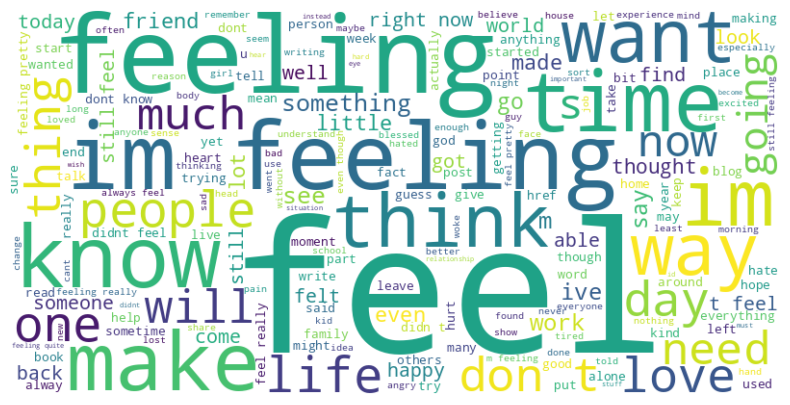

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["text"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()